# Did we get all homepages?

In [82]:
from datetime import datetime
import re
import glob
csv_files = glob.glob('../data/10-years-sfchron-homepage-csvs/*')

In [72]:
timestamps = list(map(lambda x: re.search('\d{14}', x)[0], csv_files))
timestamps = sorted(list(map(lambda x: datetime.strptime(x, '%Y%m%d%H%M%S'), timestamps)))
retrieved_dates = pd.Series(timestamps)
retrieved_dates = retrieved_dates.apply(lambda x: (x.year, x.month, x.day))

In [103]:
start_date = timestamps[0]
end_date = timestamps[-1]

In [105]:
ideal_dates = pd.Series(pd.date_range(start_date, end_date))
ideal_dates = ideal_dates.apply(lambda x: (x.year, x.month, x.day))

In [194]:
ideal_dates.isin(retrieved_dates).value_counts()

True     2202
False     283
dtype: int64

# Did we get all articles

In [3]:
import gzip
import jsonlines
import glob
import pandas as pd 
import urllib
import unidecode

def unquote_and_clean_url(x):
    if pd.isnull(x):
        return 
    url = urllib.parse.unquote(x, encoding='utf-8')
    url = unidecode.unidecode(url)
    url = url.replace(' ', '')
    if ')' in url:
        path = url.split(')')[-1]
    else:
        path = urllib.parse.urlparse(url).path
    return path.lower()

In [171]:
all_fetched_articles = []
for fname in [
    '../data/sfchron-cc-fetched-articles.jsonl.gz',
    '../data/sfchron-cc-fetched-articles-2.jsonl.gz',
    '../data/sfchron-fetched-articles.jsonl', 
]:
    if fname.endswith('.gz'):
        f = gzip.open(fname)
    else:
        f = open(fname)
    lines = list(jsonlines.Reader(f))
    all_fetched_articles += lines

In [172]:
fetched_urls = list(map(lambda x: x['article_url'], all_fetched_articles))

In [229]:
article_data_df = pd.DataFrame(all_fetched_articles)

In [173]:
all_bbs = []
for csv_file in glob.glob('../data/10-years-sfchron-homepage-csvs/*'):
    df = pd.read_csv(csv_file)
    all_bbs.append(df)
all_bb_df = pd.concat(all_bbs)

In [174]:
cleaned_article_urls = list(map(unquote_and_clean_url, fetched_urls))

In [176]:
cleaned_bb_urls = all_bb_df['href'].apply(unquote_and_clean_url)

In [ ]:
cleaned_bb_urls.isin(pd.Series(cleaned_article_urls)).value_counts()

In [198]:
import sys
sys.path.insert(0, '../scripts-homepage-data/')
import get_bounding_boxes_from_html as bb

# Process training data for model training

In [451]:
import pandas as pd
training_df = (
    pd.read_json('../modeling/data/sfchron-homepage-placement-with-topic-matches.jsonl', lines=True)
    .assign(date=lambda df: 
           df['homepage_key'].pipe(lambda s: pd.to_datetime(s, format='%Y%m%d%H%M%S'))
           )
)

<AxesSubplot:>

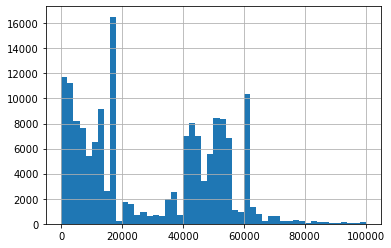

In [249]:
training_df['area'].hist(bins=50, range=(0, 100_000))

<AxesSubplot:>

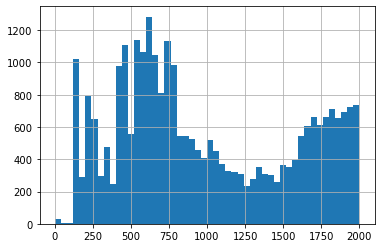

In [250]:
(training_df
 .loc[lambda df: df['area'] < 100_000]
 .loc[lambda df: df['area'] > 20_000]
 ['y'].hist(bins=50, range=(0,2000))
)

<AxesSubplot:>

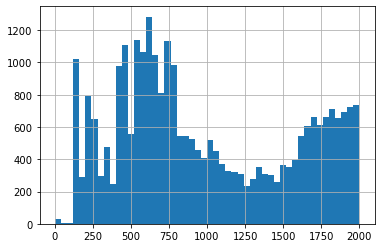

In [251]:
(training_df
 .loc[lambda df: df['area'] < 100_000]
 .loc[lambda df: df['area'] > 20_000]
 ['y'].hist(bins=50, range=(0,2000))
)

In [452]:
threshold = 1_500
training_data_for_gpt3, test_data_for_gpt3 = (
    training_df
    .loc[lambda df: df['area'] > 10_000]
    .loc[lambda df: df['area'] < 100_000]    
    .loc[lambda df: df['y'] < (threshold * 2)]
    .pipe(lambda df: 
         (df.loc[lambda df: df['date'] <= datetime(2018, 1, 1)],
          df.loc[lambda df: df['date'] > datetime(2018, 1, 1)]
         )
     )
)

# Generate Pairwise comparison for GPT3

In [476]:
from more_itertools import flatten
import random
from tqdm.auto import tqdm
from datetime import datetime


def generate_training_pairs(df, num_samples=100):
    output_samples = []
    num_samples = min(len(df), num_samples)

    idx = 0
    while len(output_samples) < num_samples:
        idx += 1
        pair = df.sample(2).sort_values('x')
        if pair.iloc[0]['y'] < pair.iloc[1]['y']:
            output_samples.append({
                'more_newsworthy_article': pair.iloc[0]['sentences'],
                'less_newsworthy_article': pair.iloc[1]['sentences'],
                'homepage': df.sample(len(df))['sentences'].tolist()
            })
            old_len_output_samples = len(output_samples)

        if idx == (num_samples* 2):
            break
    return output_samples

def make_prompt(datum, include_homepage_context=False):
    first, second = datum['more_newsworthy_article'], datum['less_newsworthy_article']
    label = (random.random() < .5)
    if label == False:
        first, second = second, first
    prompt = f'First article: \n\n"{first}"\n\n Second article: \n\n {second}'
    if include_homepage_context:
        prompt += f'\n\nRest of Homepage: {datum["homepage"]} '

    prompt += '\n\nWhich article is more newsworthy?'
    completion = '\n\n First' if label else '\n\n Second'
    return {'prompt': prompt, 'completion': completion}

def generate_pairwise_training_data(data_df):
    all_gpt3_data = []
    homepage_keys = data_df['homepage_key'].drop_duplicates()
    for key in tqdm(homepage_keys, total=len(homepage_keys)):
        df = data_df.loc[lambda df: df['homepage_key'] == key]
        if len(df) > 1:
            one_hp_training_data = generate_training_pairs(df)
            all_gpt3_data.append(one_hp_training_data)

    all_gpt3_data = list(flatten(all_gpt3_data))
    all_gpt3_data_df = (pd.DataFrame(all_gpt3_data)
     .assign(more_newsworthy_article=lambda df: df['more_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
     .assign(less_newsworthy_article=lambda df: df['less_newsworthy_article'].apply(lambda x: x[:5]).str.join(' '))
     .drop_duplicates(['more_newsworthy_article', 'less_newsworthy_article'])
     .assign(homepage=lambda df:
             df['homepage']
             .apply(lambda x: list(map(lambda y: y[0] if len(y) > 0 else '', x)))
             .str.join(' ||| ')
            )
    )

    to_filter = ['may no longer exist', 'Comments are filtered']
    for f in to_filter:
        all_gpt3_data_df = (all_gpt3_data_df
             .loc[lambda df: ~df['less_newsworthy_article'].str.contains(f)]
             .loc[lambda df: ~df['more_newsworthy_article'].str.contains(f)]
        )
    return all_gpt3_data_df

In [47]:
all_gpt3_training_data_df = generate_pairwise_training_data(training_data_for_gpt3)
prompt_completions_no_context = all_gpt3_training_data_df.apply(make_prompt, axis=1)
prompt_completions_context = all_gpt3_training_data_df.apply(make_prompt, axis=1, include_homepage_context=True)

(prompt_completions_no_context
 .to_json(
     '../modeling/pairwise-comparison-homepage-model/sfchron-gpt3-pairwise-model-no-context.jsonl', 
     orient='records', 
     lines=True
 )
)
# ft-nU9d21Lo4BnU9YvyJHvnpF4g

(prompt_completions_context
 .to_json(
     '../modeling/pairwise-comparison-homepage-model/sfchron-gpt3-pairwise-model-hp-context.jsonl', 
     orient='records', 
     lines=True
 )
)
# ft-3bZIGMd9bd3nTIYHpLjTeB2u

  0%|          | 0/1554 [00:00<?, ?it/s]

In [478]:
# topic-filtered data

topic_filtered_gpt3_training_data_df = generate_pairwise_training_data(
    training_data_for_gpt3.loc[lambda df: df['score'] > .1]
)

  0%|          | 0/1348 [00:00<?, ?it/s]

In [479]:
prompt_completions_no_context = topic_filtered_gpt3_training_data_df.apply(make_prompt, axis=1)

In [487]:
(prompt_completions_no_context
 .drop_duplicates()
 .to_json(
     '../modeling/pairwise-comparison-homepage-model/sfchron-gpt3-topic-filtered-pairwise-model-no-context.jsonl', 
     orient='records', 
     lines=True
)
)

# Generate absolute position

In [357]:
def generate_absolute_position_data(data_df, pos_start=0, pos_end=500, neg_start=800, neg_end=1_500):
    data_df = pd.concat([
        (data_df
         .loc[lambda df: df['area'] > 10_000]
         .loc[lambda df: df['area'] < 100_000]
         .loc[lambda df: (df['y'] > pos_start) & (df['y'] < pos_end)]
         .assign(label=True)
        ),
        (data_df
         .loc[lambda df: df['area'] > 10_000]
         .loc[lambda df: df['area'] < 100_000]
         .loc[lambda df:  (df['y'] > neg_start) & (df['y'] < neg_end)]
         .assign(label=False)
        )
    ]).apply(lambda x:
         {'prompt':
          f'''Is the following article newsworthy enough to appear near the top of a newspaper homepage?
          """{' '.join(x['sentences'][:5])}"""
          \n\n
          ''',
          'completion': 'Yes' if x['label'] == True else 'No'
         }
             , axis=1)
    return balance_data(data_df)

from gensim.utils import simple_preprocess
import fasttext

def balance_data(gpt3_data_df, multiplier=2):
    return (gpt3_data_df
     .drop_duplicates()
     .to_frame('data')
     .assign(label=lambda df: df['data'].apply(lambda x: x['completion']))
     .pipe(lambda df: 
           df.merge(
                df['label'].value_counts().pipe(lambda s: 1 - s / s.sum()).to_frame('sample_weight'),
                left_on='label', 
                right_index=True
            )
        )
     .pipe(lambda df: df.sample(n=len(df) * multiplier, replace=True, weights=df['sample_weight']))
     ['data']
     .reset_index(drop=True)
    )
    

def train_and_test_fasttext_model(gpt3_train_data_df, gpt3_test_data_df, resample=True):    
    # train
    fasttext_data = (gpt3_train_data_df
                     .apply(lambda x: f'__label__{x["completion"]} {" ".join(simple_preprocess(x["prompt"]))}')
                    )
    fasttext_data.to_csv('cache/2023-03-21__fasttext-sfchron-training.txt', index=False, header=False)
    model = fasttext.train_supervised('cache/2023-03-21__fasttext-sfchron-training.txt', wordNgrams = 2)
    
    # test
    fasttext_test_data = gpt3_test_data_df.apply(lambda x: ' '.join(simple_preprocess(x['prompt'])))
    fasttext_test_data_df = (gpt3_test_data_df
     .apply(lambda x: x['completion'])
     .to_frame('y_true')
     .assign(y_pred=lambda df: fasttext_test_data.apply(model.predict))
     .assign(y_pred=lambda df: df['y_pred'].apply(lambda x: x[0][0].replace('__label__','')))
     .pipe(lambda df: df['y_true'] == df['y_pred'])
    )
    return model, fasttext_test_data_df

<AxesSubplot:>

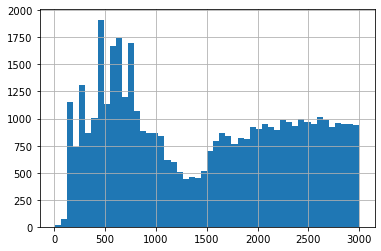

In [55]:
training_data_for_gpt3['y'].hist(bins=50)

### Explore An Absolute Position Grid

In [ ]:
fasttext_scores = []
all_combs = []
for pos_start in range(100, 300, 100):
    for pos_end in range(pos_start + 100, 1500, 200):
        for neg_start in range(pos_end, 2500, 200):
            for neg_end in range(neg_start + 50, 3000, 200):
                all_combs.append((pos_start, pos_end, neg_start, neg_end))

for pos_start, pos_end, neg_start, neg_end in tqdm(all_combs):
    absolute_position_no_context = generate_absolute_position_data(
        training_data_for_gpt3, 
        pos_start=pos_start, pos_end=pos_end, 
        neg_start=neg_start, neg_end=neg_end
    )
    absolute_position_test_data = generate_absolute_position_data(
        test_data_for_gpt3,
        pos_start=pos_start, pos_end=pos_end, 
        neg_start=neg_start, neg_end=neg_end                    
    )

    m, test_df = train_and_test_fasttext_model(absolute_position_no_context, absolute_position_test_data)
    accuracy = test_df.mean()
    fasttext_scores.append(dict(
        pos_start=pos_start, 
        pos_end=pos_end, 
        neg_start=neg_start, 
        neg_end=neg_end,
        accuracy=accuracy,
        train_df_shape=absolute_position_no_context.shape
        ) 
    )

In [359]:
fasttext_scores_df = pd.DataFrame(fasttext_scores)

In [360]:
fasttext_scores_df.loc[lambda df: df['accuracy'].idxmax()]

pos_start              100
pos_end                200
neg_start             1600
neg_end               2850
accuracy          0.748302
train_df_shape    (25888,)
Name: 83, dtype: object

In [449]:
fasttext_scores_df.loc[lambda df: df['pos_end'] == 500].sort_values('accuracy', ascending=False).head()

,pos_start,pos_end,neg_start,neg_end,accuracy,train_df_shape
636,200,500,2300,2550,0.656856,"(16064,)"
637,200,500,2300,2750,0.654768,"(19884,)"
620,200,500,1700,2350,0.653945,"(23464,)"
631,200,500,2100,2350,0.651257,"(16062,)"
634,200,500,2100,2950,0.650991,"(26836,)"


In [408]:
import sys
sys.path.insert(0, '../scripts-homepage-data/')
import get_bounding_boxes_from_html as bb

In [421]:
grids = []
for key in tqdm(training_df['homepage_key'].drop_duplicates()):
    t_df = training_df.loc[lambda df: df['homepage_key'] == key]
    t_df = (t_df
         .loc[lambda df: df['area'] > 10_000]
         .loc[lambda df: df['area'] < 100_000]
    )
    if len(t_df) > 0:
        grid = bb.get_coarsified_layout_grid(
            t_df.rename(columns={'clean_article_url': 'href'}), max_height=3000, max_width=1200
        )
        grids.append(grid)

  0%|          | 0/2325 [00:00<?, ?it/s]

In [428]:
mean_grid = sum(grids) / len(grids)

In [462]:
mean_grid.to_csv('cache/mean-grid-sfchron-area-restricted-articles.csv')

In [433]:
import seaborn as sns
import matplotlib.pyplot as plt

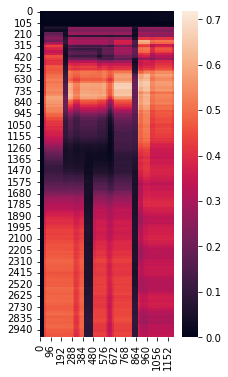

In [442]:
_, ax = plt.subplots(1, 1, figsize=(3, 6))
sns.heatmap(mean_grid, ax=ax)
xmin, xmax = ax.get_xlim()
# plt.hlines(50 , xmin, xmax)

### Explore Topic-Filtered Articles

In [467]:
# among the previous top-performing

pos_start, pos_end = 200, 500
neg_start, neg_end = 1700, 2350

In [490]:
import numpy as np 

In [495]:
fasttext_topic_scores = []
all_combs = []
for topic_filter in np.arange(.05, .3, .05):
    for pos_start in [100]:
        for pos_end in range(pos_start + 200, 1500, 250):
            for neg_start in range(pos_end, 2500, 300):
                for neg_end in range(neg_start + 50, 3000, 300):
                    all_combs.append((topic_filter, pos_start, pos_end, neg_start, neg_end))

for topic_filter, pos_start, pos_end, neg_start, neg_end in tqdm(all_combs):
    absolute_position_no_context = generate_absolute_position_data(
        training_data_for_gpt3.loc[lambda df: df['score'] > topic_filter], 
        pos_start=pos_start, pos_end=pos_end, 
        neg_start=neg_start, neg_end=neg_end
    )
    absolute_position_test_data = generate_absolute_position_data(
        test_data_for_gpt3.loc[lambda df: df['score'] > topic_filter],
        pos_start=pos_start, pos_end=pos_end, 
        neg_start=neg_start, neg_end=neg_end                    
    )

    m, test_df = train_and_test_fasttext_model(absolute_position_no_context, absolute_position_test_data)
    accuracy = test_df.mean()
    fasttext_topic_scores.append(dict(
        topic_filter=topic_filter,
        pos_start=pos_start, 
        pos_end=pos_end, 
        neg_start=neg_start, 
        neg_end=neg_end,
        accuracy=accuracy,
        train_df_shape=absolute_position_no_context.shape
        ) 
    )

  0%|          | 0/775 [00:00<?, ?it/s]

Read 0M words
Number of words:  13352
Number of labels: 2
Progress: 100.0% words/sec/thread: 2181015 lr:  0.000000 avg.loss:  0.694771 ETA:   0h 0m 0s
Read 1M words
Number of words:  23002
Number of labels: 2
Progress: 100.0% words/sec/thread: 2232630 lr:  0.000000 avg.loss:  0.694883 ETA:   0h 0m 0s
Read 1M words
Number of words:  26899
Number of labels: 2
Progress: 100.0% words/sec/thread: 2433187 lr:  0.000000 avg.loss:  0.694121 ETA:   0h 0m 0s
Read 2M words
Number of words:  29447
Number of labels: 2
Progress: 100.0% words/sec/thread: 2359155 lr:  0.000000 avg.loss:  0.682639 ETA:   0h 0m 0s
Read 2M words
Number of words:  31193
Number of labels: 2
Progress: 100.0% words/sec/thread: 2534268 lr:  0.000000 avg.loss:  0.677719 ETA:   0h 0m 0s
Read 2M words
Number of words:  33173
Number of labels: 2
Progress: 100.0% words/sec/thread: 2403333 lr:  0.000000 avg.loss:  0.676193 ETA:   0h 0m 0s
Read 2M words
Number of words:  34991
Number of labels: 2
Progress: 100.0% words/sec/thread: 2

Progress: 100.0% words/sec/thread: 2422641 lr:  0.000000 avg.loss:  0.690883 ETA:   0h 0m 0s
Read 1M words
Number of words:  28258
Number of labels: 2
Progress: 100.0% words/sec/thread: 2112093 lr:  0.000000 avg.loss:  0.689033 ETA:   0h 0m 0s
Read 1M words
Number of words:  31148
Number of labels: 2
Progress: 100.0% words/sec/thread: 2525910 lr:  0.000000 avg.loss:  0.683742 ETA:   0h 0m 0s
Read 2M words
Number of words:  33703
Number of labels: 2
Progress: 100.0% words/sec/thread: 2344073 lr:  0.000000 avg.loss:  0.667121 ETA:   0h 0m 0s
Read 2M words
Number of words:  35668
Number of labels: 2
Progress: 100.0% words/sec/thread: 2617479 lr:  0.000000 avg.loss:  0.651251 ETA:   0h 0m 0s
Read 2M words
Number of words:  37388
Number of labels: 2
Progress: 100.0% words/sec/thread: 2520232 lr:  0.000000 avg.loss:  0.639092 ETA:   0h 0m 0s
Read 0M words
Number of words:  18980
Number of labels: 2
Progress: 100.0% words/sec/thread: 2475063 lr:  0.000000 avg.loss:  0.691268 ETA:   0h 0m 0s
R

Progress: 100.0% words/sec/thread: 2524973 lr:  0.000000 avg.loss:  0.688706 ETA:   0h 0m 0s
Read 2M words
Number of words:  29452
Number of labels: 2
Progress: 100.0% words/sec/thread: 2164299 lr:  0.000000 avg.loss:  0.689536 ETA:   0h 0m 0s
Read 2M words
Number of words:  30853
Number of labels: 2
Progress: 100.0% words/sec/thread: 2413614 lr:  0.000000 avg.loss:  0.669917 ETA:   0h 0m 0s
Read 2M words
Number of words:  32079
Number of labels: 2
Progress: 100.0% words/sec/thread: 2175788 lr:  0.000000 avg.loss:  0.656101 ETA:   0h 0m 0s
Read 0M words
Number of words:  12236
Number of labels: 2
Progress: 100.0% words/sec/thread: 1762135 lr:  0.000000 avg.loss:  0.694721 ETA:   0h 0m 0s
Read 0M words
Number of words:  18825
Number of labels: 2
Progress: 100.0% words/sec/thread: 2098707 lr:  0.000000 avg.loss:  0.694750 ETA:   0h 0m 0s
Read 1M words
Number of words:  21525
Number of labels: 2
Progress: 100.0% words/sec/thread: 2757254 lr:  0.000000 avg.loss:  0.694747 ETA:   0h 0m 0s
R

Progress: 100.0% words/sec/thread: 1631656 lr:  0.000000 avg.loss:  0.694008 ETA:   0h 0m 0s
Read 0M words
Number of words:  19355
Number of labels: 2
Progress: 100.0% words/sec/thread: 2161882 lr:  0.000000 avg.loss:  0.693704 ETA:   0h 0m 0s
Read 1M words
Number of words:  23269
Number of labels: 2
Progress: 100.0% words/sec/thread: 1825088 lr:  0.000000 avg.loss:  0.693989 ETA:   0h 0m 0s
Read 1M words
Number of words:  25988
Number of labels: 2
Progress: 100.0% words/sec/thread: 1340088 lr:  0.000000 avg.loss:  0.691535 ETA:   0h 0m 0s
Read 1M words
Number of words:  27859
Number of labels: 2
Progress: 100.0% words/sec/thread: 1967912 lr:  0.000000 avg.loss:  0.684843 ETA:   0h 0m 0s
Read 1M words
Number of words:  29878
Number of labels: 2
Progress: 100.0% words/sec/thread: 2202796 lr:  0.000000 avg.loss:  0.668908 ETA:   0h 0m 0s
Read 0M words
Number of words:  15742
Number of labels: 2
Progress: 100.0% words/sec/thread: 1761596 lr:  0.000000 avg.loss:  0.688358 ETA:   0h 0m 0s
R

...

Progress: 100.0% words/sec/thread: 1827791 lr:  0.000000 avg.loss:  0.694511 ETA:   0h 0m 0s
Read 1M words
Number of words:  24264
Number of labels: 2
Progress: 100.0% words/sec/thread: 2080907 lr:  0.000000 avg.loss:  0.693494 ETA:   0h 0m 0s
Read 1M words
Number of words:  25431
Number of labels: 2
Progress: 100.0% words/sec/thread: 2296779 lr:  0.000000 avg.loss:  0.692939 ETA:   0h 0m 0s
Read 0M words
Number of words:  14838
Number of labels: 2
Progress: 100.0% words/sec/thread: 1547488 lr:  0.000000 avg.loss:  0.650255 ETA:   0h 0m 0s
Read 0M words
Number of words:  17782
Number of labels: 2
Progress: 100.0% words/sec/thread: 1865514 lr:  0.000000 avg.loss:  0.694621 ETA:   0h 0m 0s
Read 0M words
Number of words:  20123
Number of labels: 2
Progress: 100.0% words/sec/thread: 2205616 lr:  0.000000 avg.loss:  0.694794 ETA:   0h 0m 0s
Read 0M words
Number of words:  21704
Number of labels: 2
Progress: 100.0% words/sec/thread: 2538720 lr:  0.000000 avg.loss:  0.694516 ETA:   0h 0m 0s
R

Read 1M words
Number of words:  22465
Number of labels: 2
Progress: 100.0% words/sec/thread: 1946488 lr:  0.000000 avg.loss:  0.693883 ETA:   0h 0m 0s
Read 1M words
Number of words:  24154
Number of labels: 2
Progress: 100.0% words/sec/thread: 2112231 lr:  0.000000 avg.loss:  0.693695 ETA:   0h 0m 0s
Read 1M words
Number of words:  25696
Number of labels: 2
Progress: 100.0% words/sec/thread: 2307837 lr:  0.000000 avg.loss:  0.692429 ETA:   0h 0m 0s
Read 0M words
Number of words:  17407
Number of labels: 2
Progress: 100.0% words/sec/thread: 2187817 lr:  0.000000 avg.loss:  0.601079 ETA:   0h 0m 0s
Read 0M words
Number of words:  20427
Number of labels: 2
Progress: 100.0% words/sec/thread: 2603606 lr:  0.000000 avg.loss:  0.693791 ETA:   0h 0m 0s
Read 1M words
Number of words:  22631
Number of labels: 2
Progress: 100.0% words/sec/thread: 1956284 lr:  0.000000 avg.loss:  0.694233 ETA:   0h 0m 0s
Read 1M words
Number of words:  24206
Number of labels: 2
Progress: 100.0% words/sec/thread: 2

Progress: 100.0% words/sec/thread: 1618577 lr:  0.000000 avg.loss:  0.695042 ETA:   0h 0m 0s
Read 0M words
Number of words:  15290
Number of labels: 2
Progress: 100.0% words/sec/thread: 2429283 lr:  0.000000 avg.loss:  0.695058 ETA:   0h 0m 0s
Read 0M words
Number of words:  16712
Number of labels: 2
Progress: 100.0% words/sec/thread: 1554833 lr:  0.000000 avg.loss:  0.695040 ETA:   0h 0m 0s
Read 0M words
Number of words:  17403
Number of labels: 2
Progress: 100.0% words/sec/thread: 1740560 lr:  0.000000 avg.loss:  0.695069 ETA:   0h 0m 0s
Read 0M words
Number of words:  18708
Number of labels: 2
Progress: 100.0% words/sec/thread: 1973185 lr:  0.000000 avg.loss:  0.694999 ETA:   0h 0m 0s
Read 0M words
Number of words:  19659
Number of labels: 2
Progress: 100.0% words/sec/thread: 2212134 lr:  0.000000 avg.loss:  0.695001 ETA:   0h 0m 0s
Read 0M words
Number of words:  20463
Number of labels: 2
Progress: 100.0% words/sec/thread: 2501862 lr:  0.000000 avg.loss:  0.695016 ETA:   0h 0m 0s
R

Read 0M words
Number of words:  21436
Number of labels: 2
Progress: 100.0% words/sec/thread: 2486297 lr:  0.000000 avg.loss:  0.694422 ETA:   0h 0m 0s
Read 0M words
Number of words:  13119
Number of labels: 2
Progress: 100.0% words/sec/thread: 2541915 lr:  0.000000 avg.loss:  0.693302 ETA:   0h 0m 0s
Read 0M words
Number of words:  15717
Number of labels: 2
Progress: 100.0% words/sec/thread: 1360714 lr:  0.000000 avg.loss:  0.694589 ETA:   0h 0m 0s
Read 0M words
Number of words:  17669
Number of labels: 2
Progress: 100.0% words/sec/thread: 1762466 lr:  0.000000 avg.loss:  0.694595 ETA:   0h 0m 0s
Read 0M words
Number of words:  19262
Number of labels: 2
Progress: 100.0% words/sec/thread: 2035654 lr:  0.000000 avg.loss:  0.694733 ETA:   0h 0m 0s
Read 0M words
Number of words:  20826
Number of labels: 2
Progress: 100.0% words/sec/thread: 2294977 lr:  0.000000 avg.loss:  0.694793 ETA:   0h 0m 0s
Read 0M words
Number of words:  12947
Number of labels: 2
Progress: 100.0% words/sec/thread: 1

Read 0M words
Number of words:  17641
Number of labels: 2
Progress: 100.0% words/sec/thread: 1922029 lr:  0.000000 avg.loss:  0.694818 ETA:   0h 0m 0s
Read 0M words
Number of words:  19531
Number of labels: 2
Progress: 100.0% words/sec/thread: 2170475 lr:  0.000000 avg.loss:  0.694798 ETA:   0h 0m 0s


In [500]:
fasttext_topic_scores_df = pd.DataFrame(fasttext_topic_scores)

In [512]:
fasttext_topic_scores_df.sort_values('accuracy', ascending=False).loc[lambda df: df['topic_filter'] == .1]

,topic_filter,pos_start,pos_end,neg_start,neg_end,accuracy,train_df_shape
264,0.1,100,800,2300,2350,0.626807,"(9992,)"
306,0.1,100,1300,1900,2850,0.624193,"(20034,)"
232,0.1,100,550,2350,2400,0.623780,"(5900,)"
309,0.1,100,1300,2200,2850,0.621107,"(18182,)"
283,0.1,100,1050,1650,2600,0.620766,"(18376,)"
...,...,...,...,...,...,...,...
173,0.1,100,300,900,1250,0.490810,"(4910,)"
181,0.1,100,300,1200,1850,0.486904,"(5648,)"
197,0.1,100,300,2400,2450,0.485887,"(2450,)"
155,0.1,100,300,300,350,0.483471,"(2478,)"


In [518]:
topic_restricted_grids = []
topic_restricted_df = training_df.loc[lambda df: df.score > .1]
for key in tqdm(topic_restricted_df['homepage_key'].drop_duplicates()):
    t_df = topic_restricted_df.loc[lambda df: df['homepage_key'] == key]
    t_df = (t_df
         .loc[lambda df: df['area'] > 10_000]
         .loc[lambda df: df['area'] < 100_000]
    )
    if len(t_df) > 0:
        grid = bb.get_coarsified_layout_grid(
            t_df.rename(columns={'clean_article_url': 'href'}), max_height=3000, max_width=1200
        )
        topic_restricted_grids.append(grid)

  0%|          | 0/2133 [00:00<?, ?it/s]

In [520]:
mean_topic_restricted_grid = sum(topic_restricted_grids) / len(topic_restricted_grids)

<AxesSubplot:>

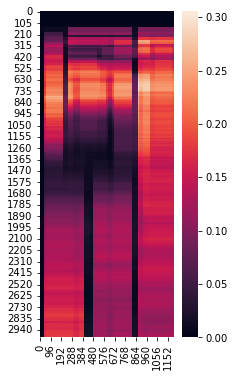

In [523]:
_, ax = plt.subplots(1, 1, figsize=(3, 6))
sns.heatmap(mean_topic_restricted_grid)

# Get Real Examples

In [524]:
pos_start, pos_end = 100, 1050
neg_start, neg_end = 1650, 2600


# 200	500	1700	2350

In [631]:
absolute_position_no_context = generate_absolute_position_data(
    training_data_for_gpt3.loc[lambda df: df['score'] > .1], 
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end
)
absolute_position_test_data = generate_absolute_position_data(
    test_data_for_gpt3.loc[lambda df: df['score'] > .1],
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end                    
)

In [632]:
m, test_df = train_and_test_fasttext_model(absolute_position_no_context, absolute_position_test_data)

Read 2M words
Number of words:  32118
Number of labels: 2
Progress: 100.0% words/sec/thread: 2220824 lr:  0.000000 avg.loss:  0.646298 ETA:   0h 0m 0s2221351 lr: -0.000012 avg.loss:  0.646298 ETA:   0h 0m 0s


In [633]:
test_df.mean()

0.6199186991869918

In [540]:
meeting_minutes_with_summary = (
    pd.read_csv('../data/city-council-meeting-minutes/new-agenda-watch-with-gpt3-summaries.csv', index_col=0)
)

In [634]:
from more_itertools import flatten

flat_bullet_point_list = list(flatten(
    meeting_minutes_with_summary['summary']
        .str.split('\n')
        .apply(lambda x: list(map(lambda y: y.strip(), x)))
        .to_list()
))

In [635]:
flat_bullet_point_list = pd.Series(flat_bullet_point_list).value_counts().loc[lambda s: s ==1].index.tolist()

In [636]:
labels, probs = m.predict(flat_bullet_point_list)

In [637]:
y_pred_df = pd.concat([
    pd.Series(labels).str.get(0).to_frame('y_pred'),
    pd.Series(probs).str.get(0).to_frame('y_prob')
], axis=1)

In [638]:
y_prob = y_pred_df.apply(lambda x: x['y_prob'] if x['y_pred'] == '__label__Yes' else 1 - x['y_prob'], axis=1)

In [639]:
(y_prob
 .to_frame('y_prob')
 .assign(text=flat_bullet_point_list)
 .sort_values('y_prob', ascending=False)
 ['text'].head(20).values.tolist()
)

['- Fiscal year 2013-2015 adopted police budget',
 '- Monthly police staffing levels',
 '-Quarterly report regarding police training, policy & accountability',
 '-Unfinished Business – none was reported',
 '- Adjournment: The meeting was adjourned.',
 '- Police training, policy, and accountability, including information regarding internal affairs investigations, police personnel trainings, updates to police policy, and recent developments in police discipline',
 '- Bikes on BART was discussed',
 '- Inquiry into the police interaction with a Hayward resident',
 '- Pledging of Allegiance was made.',
 '-La Pinata police officer fundraiser for the Special Olympics',
 '- Manditory Ethics Training was given',
 '- Government Code Section 54954.2 was discussed',
 '- A Public Comment period was opened.',
 '-Comments by Councilmembers were made.',
 '- Decision-application was approved by the Hearing Officer',
 '-Non-conformance to city requirements',
 '- Reminder to complete Ethics Training was 

In [630]:
(y_prob
 .to_frame('y_prob')
 .assign(text=flat_bullet_point_list)
 .sort_values('y_prob', ascending=False)
 ['text'].head(20).values.tolist()
)

['-Agenda review',
 '- Traffic issues on highway 85',
 '- Monthly police staffing levels',
 '- Plastic bag ban',
 '- Calendar review',
 '-CAC member comments',
 '- Discussion of new server crash of CLASS software',
 '- Declaration of a medical cannabis health emergency',
 '- Medical Cannabis health emergency',
 '- Stay-in car service',
 '- No correspondence reported',
 '- Placemaking events',
 '- Correspondence for review',
 '- Environmental review report',
 '- Prudent budgeting for the future',
 '- Upcoming events',
 '- Discussed upcoming speakers for future meetings',
 '- Reports on closed session actions taken',
 '- Notification options for events & programs',
 '- Requests for deferral to a future meeting date']

## Run Models on GPT3

In [297]:
absolute_position_no_context.apply(lambda x: x['completion']).value_counts().pipe(lambda s: 1 - s / s.sum())

No     0.485418
Yes    0.514582
dtype: float64

In [448]:
pos_start, pos_end =200, 500
neg_start, neg_end =1700, 2350

absolute_position_no_context = generate_absolute_position_data(
    training_data_for_gpt3,
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end
)

absolute_position_test_data = generate_absolute_position_data(
    test_data_for_gpt3,
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end
)

(absolute_position_no_context
 .drop_duplicates()
 .to_json(
     f'../modeling/absolute-position-homepage-model/sfchron-gpt3-absolute-position-no-context__{pos_start}-{pos_end}_{neg_start}-{neg_end}_training_data.jsonl',
     orient='records', 
     lines=True
 )
)

In [513]:
topic_filter = 0.1
pos_start, pos_end = 100, 1300
neg_start, neg_end = 1900, 2850

absolute_position_no_context = generate_absolute_position_data(
    training_data_for_gpt3.loc[lambda df: df['score'] > topic_filter],
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end
)

absolute_position_test_data = generate_absolute_position_data(
    test_data_for_gpt3.loc[lambda df: df['score'] > topic_filter],
    pos_start=pos_start, pos_end=pos_end, 
    neg_start=neg_start, neg_end=neg_end
)

(absolute_position_no_context
 .drop_duplicates()
 .to_json(
     f'../modeling/absolute-position-homepage-model/sfchron-gpt3-absolute-position-no-context__topic-filtered__{pos_start}-{pos_end}_{neg_start}-{neg_end}_training_data.jsonl',
     orient='records', 
     lines=True
 )
)

In [267]:
import openai
from transformers import AutoTokenizer

openai.api_key_path = "/Users/spangher/.openai-isi-key.txt"
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [268]:
absolute_position_model_name = "babbage:ft-isi-nlp-2023-03-22-05-23-50"
to_test = absolute_position_test_data.sample(5_000)
position_test_batch_completions = []

for prompt in tqdm(to_test.apply(lambda x: x['prompt']).iloc[len(position_test_batch_completions):]):
    if len(tokenizer.encode(prompt)) > 2040:
        completion_text = ''
    else:
        completion = openai.Completion.create(
              model=absolute_position_model_name,
              prompt=prompt,
              max_tokens=3
            )

        completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    position_test_batch_completions.append(completion_text)

  0%|          | 0/5000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1045 > 1024). Running this sequence through the model will result in indexing errors


In [269]:
gpt3_position_preds = pd.Series(position_test_batch_completions)
y_true = to_test.apply(lambda x: x['completion']).str.strip()
y_true.value_counts()

Yes    2512
No     2488
dtype: int64

In [277]:
results_df = (pd.concat([
                    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
                    y_true.str.lower().to_frame('y_true').reset_index(drop=True),
#                     gpt3_position_preds.str.replace(',', '').str.split().apply(lambda x: pd.Series(x).value_counts().index[0]).to_frame('y_pred')
                    gpt3_position_preds.str.split().str.get(0).to_frame('y_pred')
        ], axis=1)
    # add sampling weights
#     .pipe(lambda df:
#                      df.merge(
#                          df['y_true'].value_counts().pipe(lambda s: 1 - (s / s.sum())).to_frame('weights').reset_index().rename(columns={'index': 'y_true'}),
#                          on='y_true'
#                      )
#      )
)

In [279]:
results_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.5668

# Evalute models

In [3]:
import openai
import os

In [18]:
openai.api_key_path = os.path.expanduser('~/.openai-isi-key.txt')

In [ ]:
# models (SF Chron)

# Absolute position, no context
# Model Name: "babbage:ft-isi-nlp-2023-03-17-05-05-42"
# Model training data file: "sfchron-gpt3-absolute-position-no-context_prepared.jsonl"
# Model Name: "babbage:ft-isi-nlp-2023-03-21-02-26-27"
# Model training data file: sfchron-gpt3-absolute-position-no-context__training_data_prepared.jsonl

# Pairwise comparison, no context
# Model Name: "babbage:ft-isi-nlp-2023-03-17-04-15-10"
# Model training data file: "sfchron-gpt3-pairwise-model-no-context_prepared.jsonl"

In [168]:
from sklearn.metrics import f1_score
import numpy as np

In [71]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [84]:
absolute_position_no_context = generate_absolute_position_data(test_data_for_gpt3).drop_duplicates()

In [ ]:
absolute_position_model_name = "babbage:ft-isi-nlp-2023-03-21-02-26-27"
to_test = absolute_position_no_context.sample(5_000)
position_test_batch_completions = []

for prompt in tqdm(to_test.apply(lambda x: x['prompt']).iloc[len(position_test_batch_completions):]):
    if len(tokenizer.encode(prompt)) > 2040:
        completion_text = ''
    else:
        completion = openai.Completion.create(
              model=absolute_position_model_name,
              prompt=prompt,
              max_tokens=5
            )

        completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    position_test_batch_completions.append(completion_text)

In [94]:
gpt3_position_preds = pd.Series(position_test_batch_completions)
y_true = to_test.apply(lambda x: x['completion']).str.strip()
y_true.value_counts()

No     3051
Yes    1949
dtype: int64

In [151]:
results_df = (pd.concat([
                    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
                    y_true.str.lower().to_frame('y_true').reset_index(drop=True),
                    gpt3_position_preds.str.replace(',', '').str.split().apply(lambda x: pd.Series(x).value_counts().index[0]).to_frame('y_pred')
                    # gpt3_position_preds.str.split().str.get(0).to_frame('y_pred')
        ], axis=1)
    # add sampling weights
    .pipe(lambda df:
                     df.merge(
                         df['y_true'].value_counts().pipe(lambda s: 1 - (s / s.sum())).to_frame('weights').reset_index().rename(columns={'index': 'y_true'}),
                         on='y_true'
                     )
     )
)

In [166]:
upsampled_results_df = results_df.sample(n=2 * len(results_df), replace=True, weights=results_df['weights'])

In [167]:
upsampled_results_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.5679

In [169]:
upsampled_results_df['y_pred'].value_counts()

yes    5970
no     4030
Name: y_pred, dtype: int64

In [171]:
upsampled_results_df.pipe(lambda df: f1_score(df['y_true'], df['y_pred'], pos_label='yes'))

0.6107557877668679

In [172]:
upsampled_results_df.pipe(lambda df: f1_score(df['y_true'], np.random.choice(['yes', 'no'], size=len(df)), pos_label='yes'))

0.5121347201584944

In [175]:
completion = openai.Completion.create(
              model=absolute_position_model_name,
              prompt=prompt,
              max_tokens=1,
              logprobs=1
            )

In [177]:
completion.to_dict_recursive()

{'id': 'cmpl-6wMqYul5RZZuUQDb340Lpzwchjlzw',
 'object': 'text_completion',
 'created': 1679368866,
 'model': 'babbage:ft-isi-nlp-2023-03-21-02-26-27',
 'choices': [{'text': ' yes',
   'index': 0,
   'logprobs': {'tokens': [' yes'],
    'token_logprobs': [-0.94466025],
    'top_logprobs': [{' no': -0.49250045}],
    'text_offset': [915]},
   'finish_reason': 'length'}],
 'usage': {'prompt_tokens': 209, 'completion_tokens': 1, 'total_tokens': 210}}

In [57]:
test_pairwise_comparison = generate_pairwise_training_data(test_data_for_gpt3)

  0%|          | 0/716 [00:00<?, ?it/s]

In [58]:
test_prompt_completions_no_context = test_pairwise_comparison.apply(make_prompt, axis=1)

In [60]:
test_prompt_completions_no_context.iloc[0]

{'prompt': 'First article: \n\n"Latest developments on the PG&E shut-offs. Click here for the latest news story: 9: 02 p. m. Power restored to 99% of customer accounts in Bay Area: PG&E said 99% of Bay Area customer accounts that were impacted by its shutoff had their power restored. 8: 52 p. m. Power restored to 97% of customer accounts statewide: PG&E said 97% of customer accounts that were impacted by its shutoff had their power restored. Roughly 21,000 customer accounts remain without power, PG&E officials said. Restoration efforts are expected to continue through "daybreak" Saturday."\n\n Second article: \n\n The Blue Angels will always be a simmering debate in San Francisco. Until the city\'s dogs get organized enough to hire a lobbyist, the Navy precision flying team will almost certainly continue its multi-decade tradition of flying above and between our city\'s landmarks during San Francisco Fleet Week. But no modern controversy compares to the great Blue Angels panic of 1983,

In [ ]:
no_context_model_name = "babbage:ft-isi-nlp-2023-03-17-04-15-10"
to_test = test_prompt_completions_no_context.sample(5_000)
test_batch_completions = []
for prompt in tqdm(to_test.apply(lambda x: x['prompt']).iloc[len(test_batch_completions):]):
    if len(tokenizer.encode(prompt)) > 2040:
        completion_text = ''
    else:
        completion = openai.Completion.create(
              model=no_context_model_name,
              prompt=prompt,
              max_tokens=5
            )

        completion_text = completion.to_dict_recursive()['choices'][0]['text'].strip()
    test_batch_completions.append(completion_text)

In [73]:
gpt3_preds = pd.Series(test_batch_completions)
y_true = to_test.apply(lambda x: x['completion']).str.strip()
y_true.value_counts()

Second    2515
First     2485
dtype: int64

In [77]:
results_df = pd.concat([
    to_test.apply(lambda x: x['prompt']).str.strip().to_frame('prompt').reset_index(drop=True),
    y_true.to_frame('y_true').reset_index(drop=True),
    gpt3_preds.apply(lambda x: 'First' if 'first' in x.lower() else 'Second').to_frame('y_pred')
], axis=1)

In [78]:
results_df.apply(lambda x: x['y_true'] == x['y_pred'], axis=1).mean()

0.6834

In [93]:
results_df.to_csv('../modeling/pairwise-comparison-homepage-model/sfchron-gpt3-pairwise-model-no-context__test_results.csv', index=False)